<a href="https://colab.research.google.com/github/Jana-Alothman/GP1/blob/main/Jana_Text_Classification_ML_Models_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Collection**

**Dataset Source:**

In this project, the dataset used for Arabic readability assessment was obtained from BAREC Corpus v1.0 on Hugging Face.

---
**Research paper:**

A Large and Balanced Corpus for Fine-grained Arabic Readability Assessment.

---

**Data Fields:**
- ID: Unique sentence identifier.
- Sentence: The sentence text.
- Word_Count: Number of words in the sentence.
- Word: Simply tokenized and dediacritized sentences.
- Lex: Each word is replaced by its predicited lemma (dediacritized).
- D3Tok: We tokenize words into their base and clitics forms.
- D3Lex: We replace the base forms in D3Tok with the predicited lemmas.
- Readability_Level: The readability level in 19-levels scheme, ranging from 1-alif to 19-qaf.
- Readability_Level_19: The readability level in 19-levels scheme, ranging from 1 to 19.
- Readability_Level_7: The readability level in 7-levels scheme, ranging from 1 to 7.
- Readability_Level_5: The readability level in 5-levels scheme, ranging from 1 to 5.
- Readability_Level_3: The readability level in 3-levels scheme, ranging from 1 to 3.
- Annotator: The annotator ID (A1-A5 or IAA).
- Document: Source document file name.
- Source: Document source.
- Book: Book name.
- Author: Author name.
- Domain: Domain (Arts & Humanities, STEM or Social Sciences).
- Text_Class: Readership group (Foundational, Advanced or Specialized).

---
**Supported Tasks:**

The dataset supports multi-class readability classification in the following formats:

- 19 levels (default)
- 7 levels
- 5 levels
- 3 levels

---
**Data Splits:**
- The BAREC dataset has three splits: Train (80%), Dev (10%), and Test (10%).
- The splits are in the document level.
- The splits are balanced accross Readability Levels, Domains, and Text Classes.



In [35]:
# Install required libraries for dataset loading and processing.

!pip install datasets pandas

In [36]:
# Load the BAREC dataset and display dataset splits and columns.

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

# Load each split separately
train_df = dataset["train"].to_pandas()
dev_df = dataset["dev"].to_pandas()
test_df = dataset["test"].to_pandas()
full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

# Display split sizes
print("Train Shape:", train_df.shape)
print("Validation Shape:", dev_df.shape)
print("Test Shape:", test_df.shape)
print("Full Dataset Shape:", full_df.shape)

print("\nDataset Columns:\n")
print(full_df.columns)

print("\nSample Data:\n")
full_df.head()

Train Shape: (54845, 19)
Validation Shape: (7310, 19)
Test Shape: (7286, 19)
Full Dataset Shape: (69441, 19)

Dataset Columns:

Index(['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex',
       'Readability_Level', 'Readability_Level_19', 'Readability_Level_7',
       'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document',
       'Source', 'Book', 'Author', 'Domain', 'Text_Class'],
      dtype='object')

Sample Data:



,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [37]:
# Save the complete dataset as a CSV file.

full_df.to_csv("BAREC_full.csv", index=False)

In [38]:
# Create a filtered version containing selected columns only.

filtered_full_df = full_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19"
]]

filtered_train_df = train_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19"
]]

filtered_dev_df = dev_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19"
]]

filtered_test_df = test_df[[
    "Word",
    "Word_Count",
    "Domain",
    "Text_Class",
    "Readability_Level_19"
]]

filtered_full_df.to_csv("BAREC_full_filtered.csv", index=False)
filtered_full_df.head()

,Word,Word_Count,Domain,Text_Class,Readability_Level_19
0,مجلة كل الأولاد وكل البنات,5,Arts & Humanities,Foundational,7
1,ماجد,1,Arts & Humanities,Foundational,1
2,الأربعاء 21 يناير 1987,4,Arts & Humanities,Foundational,8
3,الموافق 21 جمادى الأول 1407ه,6,Arts & Humanities,Foundational,7
4,السنة الثامنة,2,Arts & Humanities,Foundational,5


**Feature Selection Justification**

The following columns were removed to avoid data leakage and to ensure that the model learns only from meaningful and independent input features.

---

**Text Variations (Sentence, Lex, D3Tok, D3Lex)**

These columns are different linguistic transformations of the same sentence.

- They represent the same original text in different formats  
- Including them would cause data leakage
- The model would learn repeated versions of the same information instead of real patterns

---

**Alternative Readability Levels (3, 5, 7-level schemes)**

These columns represent the same target variable (readability) but on different scales.

- They contain overlapping information with the main target (19-level scale)
- Using them would introduce redundancy
- They could indirectly leak target information into the model

---

**Metadata Columns (ID, Annotator, Document, Source, Book, Author)**

These columns are not useful for prediction.

- They are administrative or contextual only
- They do not contribute to readability prediction
- They may introduce unnecessary noise or bias

---

**Final Selected Features**

The final dataset used for modeling includes:

- **Word** → main input text
- **Word_Count** → length-based feature
- **Domain** → topic/category information
- **Text_Class** → readership group
- **Readability_Level_19** → target label

In [39]:
# Download both the full and filtered datasets.

from google.colab import files

#files.download("BAREC_full.csv")
#files.download("BAREC_full_filtered.csv")


# **Data Preprocessing**

In this stage, we perform preprocessing on the **filtered dataset** to ensure it is clean, consistent, and ready for machine learning.

## 1. Checking Missing Values

We first check whether the dataset contains any missing values.

Even if the dataset is clean, this step ensures there are no hidden nulls that could affect model training.

In [40]:
filtered_full_df.isnull().sum()

,0
Word,0
Word_Count,0
Domain,0
Text_Class,0
Readability_Level_19,0


**Interpretation:** The dataset shows no missing values across all selected features, indicating that the data is complete and well-structured.

## 2. Checking Duplicate Rows

We check for duplicate rows to make sure the model does not learn repeated examples that could bias training.

In [41]:
beforeFull = filtered_full_df.duplicated().sum()
beforeTrain = filtered_train_df.duplicated().sum()
beforeDev = filtered_dev_df.duplicated().sum()
beforeTest = filtered_test_df.duplicated().sum()

print("Before dropping duplicates (Full) = " , beforeFull)
print("Before dropping duplicates (Train) = " , beforeTrain)
print("Before dropping duplicates (Dev) = " , beforeDev)
print("Before dropping duplicates (Test) = " , beforeTest)

Before dropping duplicates (Full) =  3542
Before dropping duplicates (Train) =  2670
Before dropping duplicates (Dev) =  195
Before dropping duplicates (Test) =  213


In [42]:
afterFull = filtered_full_df.drop_duplicates().duplicated().sum()
afterTrain = filtered_train_df.drop_duplicates().duplicated().sum()
afterDev = filtered_dev_df.drop_duplicates().duplicated().sum()
afterTest = filtered_test_df.drop_duplicates().duplicated().sum()

print("After dropping duplicates (Full) = " , afterFull)
print("After dropping duplicates (Train) = " , afterTrain)
print("After dropping duplicates (Dev) = " , afterDev)
print("After dropping duplicates (Test) = " , afterTest)

After dropping duplicates (Full) =  0
After dropping duplicates (Train) =  0
After dropping duplicates (Dev) =  0
After dropping duplicates (Test) =  0


**Interpretation:** 3,542 duplicate rows were found in the dataset, indicating repeated samples. These duplicates were removed to prevent bias and ensure the model does not learn from repeated instances of the same data.

## 3. Checking Label Distribution

We analyze the distribution of the 19-level readability classes to understand whether the dataset is balanced or imbalanced.

In [43]:
filtered_full_df["Readability_Level_19"].value_counts().sort_index()

,count
Readability_Level_19,
1,409
2,437
3,1462
4,751
5,3443
6,1534
7,5438
8,5683
9,2023


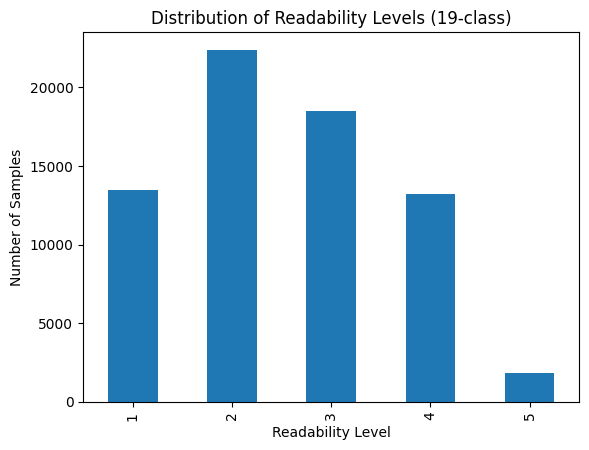

In [44]:
import matplotlib.pyplot as plt

full_df["Readability_Level_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Readability Levels (19-class)")
plt.xlabel("Readability Level")
plt.ylabel("Number of Samples")

plt.show()

**Interpretation:** The dataset shows a clear class imbalance across the 19 readability levels. Some classes (e.g., levels 10–14) contain a significantly higher number of samples, while higher levels such as 18 and 19 have very few instances. This imbalance may affect model performance and bias predictions toward majority classes.


**Recommendation:** During model training, it is recommended to handle the class imbalance by setting `class_weight="balanced"` in the classifier. This helps the model give appropriate importance to minority readability levels and reduces bias toward majority classes, leading to more reliable predictions across all 19 classes.

**Evaluation Metrics Overview:**

The model is evaluated using multiple metrics to properly reflect its performance on an ordinal 19-level readability classification task.

- **Quadratic Weighted Kappa (QWK):** Primary metric that measures agreement between predicted and actual labels while penalizing larger errors more heavily.
- **Accuracy (Acc19 Dist):** Measures exact match between predicted and true labels.
- **Acc19 ±1:** Considers predictions correct if they are within one level of the true label.
- **Macro F1-score:** Evaluates performance equally across all classes, making it suitable for imbalanced datasets.
- **Precision & Recall:** Measure class-level prediction quality and coverage.
- **Confusion Matrix:** Provides detailed insight into misclassification patterns.
- **MAE/Distance (Mean Absolute Error)**: The average absolute difference between predicted and true values. Treats all errors equally. Lower is better.
- **RMSE (Root Mean Square Error):** The square root of the average squared difference between predicted and true values. Penalizes large errors more heavily than MAE. Lower is better.
- **R² Score:** Indicates how well predictions explain variance in readability levels, though less common for classification tasks.

**The difference between RMSE & QWK**


The key difference between MAE/RMSE and Quadratic Weighted Kappa (QWK) is that MAE and RMSE simply measure how many levels the model is **off** by on average, treating the problem like a regression task. QWK, on the other hand, measures **agreement** between predictions and true labels while correcting for chance agreement and applying a quadratic penalty to larger errors.

This means that a mistake of one level is penalized much less than a mistake of five levels. QWK is better for the BAREC dataset because readability assessment is an ordinal classification problem, where the 19 levels have a natural order but the gaps between them are not equal.

Additionally, QWK handles imbalanced data well, which is important since some levels in BAREC have very few sentences. For these reasons, the BAREC paper used QWK as their primary evaluation metric.

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Use Word as input and Readability_Level_19 as target
X_text = filtered_train_df['Word']
y = filtered_train_df['Readability_Level_19']

# Convert text to numerical features using TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X = tfidf.fit_transform(X_text)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (54845, 10000)
Labels shape: (54845,)


**Train-Test Split**

In this step, we divide the dataset into two parts: a training set used to fit the model, and a test set used to evaluate its performance on unseen data. We allocate 80% of the data for training and 20% for testing. The stratify parameter ensures that the distribution of readability levels is preserved proportionally in both splits, which is important given the class imbalance observed in the dataset.

In [46]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ensures balanced class distribution in both splits
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 43876
Test size: 10969


#**Model Training**

In this step, we initialize and train a Random Forest classifier on the training data. Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. We set class_weight='balanced' to handle the class imbalance identified during the data analysis phase, ensuring that minority readability levels are not ignored during training.

##**Random Forest Model (19 Levels)**

**Why Random Forest?**

Random Forest was chosen because it is a strong and reliable machine learning algorithm that combines multiple decision trees to improve prediction performance and reduce overfitting. It works well with TF-IDF numerical text features and can handle multi-class classification problems such as the 19-level Arabic readability task. In addition, since the dataset is imbalanced, class_weight="balanced" was used to reduce bias toward classes with more samples.


In [47]:
# Random Forest supports labels starting from 1, no adjustment needed
y_train = filtered_train_df['Readability_Level_19']
y_test  = filtered_test_df['Readability_Level_19']

print("Original label range:", y_train.min(), "to", y_train.max())

Original label range: 1 to 19


In [48]:
#Feature Extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Use Word column as input text
X_train_text = filtered_train_df['Word']
X_test_text  = filtered_test_df['Word']

# Fit TF-IDF on TRAINING data only
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

Training features shape: (54845, 10000)
Test features shape: (7286, 10000)


In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5]
}

In [58]:
from sklearn.model_selection import GridSearchCV

rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

**Hyperparameter Tuning**

Hyperparameter tuning is the process of systematically searching for the optimal configuration of a model's settings prior to training. Unlike model parameters, which are learned automatically from data, hyperparameters must be defined manually before the training process begins. In this work, we applied a manual grid search strategy to identify the combination of hyperparameters that maximizes the Quadratic Weighted Kappa (QWK) score on the test set.



In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score
import numpy as np
import pandas as pd

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50 , 100 , 200 , 250 , 300 , 350 , 400 , 450],
    'max_depth': [None, 5 , 10 , 15 , 20],
    'min_samples_split': [2, 5 , 7 , 10]
}

results = []
best_acc = -1
best_params = None
best_model = None

total = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])
count = 0

print(f"Total combinations to try: {total}\n")

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for min_split in param_grid['min_samples_split']:
            count += 1
            print(f"[{count}/{total}] Testing: n_estimators={n_est}, max_depth={depth}, min_samples_split={min_split}")

            # Train model
            model = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_split=min_split,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train, y_train)

            # Evaluate
            y_pred = model.predict(X_test)
            acc     = accuracy_score(y_test, y_pred)
            adj_acc = np.mean(np.abs(y_pred - y_test) <= 1)
            qwk     = cohen_kappa_score(y_test, y_pred, weights='quadratic')
            mae     = np.mean(np.abs(y_pred - y_test))

            results.append({
                'n_estimators': n_est,
                'max_depth': depth,
                'min_samples_split': min_split,
                'Accuracy': round(acc, 4),
                'Adj_Accuracy': round(adj_acc, 4),
                'QWK': round(qwk, 4),
                'MAE': round(mae, 4)
            })

            # Track best model based on Accuracy
            if acc > best_acc:
                best_acc = acc
                best_params = {'n_estimators': n_est, 'max_depth': depth, 'min_samples_split': min_split}
                best_model = model

            print(f"         → Accuracy={acc:.4f} | Adj={adj_acc:.4f} | QWK={qwk:.4f} | MAE={mae:.4f}\n")

# Show full results table sorted by Accuracy
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n===== Full Results (Sorted by Accuracy) =====")
print(results_df.to_string(index=False))

# Show best combination
print("\n===== Best Combination =====")
print(f"n_estimators    : {best_params['n_estimators']}")
print(f"max_depth       : {best_params['max_depth']}")
print(f"min_samples_split: {best_params['min_samples_split']}")
print(f"Best Accuracy   : {best_acc:.4f}")

# Save best model
import joblib
joblib.dump(best_model, 'rf_best_model.pkl')
print("\nBest model saved as rf_best_model.pkl")

Total combinations to try: 160

[1/160] Testing: n_estimators=50, max_depth=None, min_samples_split=2
         → Accuracy=0.3501 | Adj=0.4697 | QWK=0.5027 | MAE=2.2303

[2/160] Testing: n_estimators=50, max_depth=None, min_samples_split=5
         → Accuracy=0.3544 | Adj=0.4756 | QWK=0.5037 | MAE=2.2492

[3/160] Testing: n_estimators=50, max_depth=None, min_samples_split=7
         → Accuracy=0.3514 | Adj=0.4750 | QWK=0.5013 | MAE=2.2660

[4/160] Testing: n_estimators=50, max_depth=None, min_samples_split=10
         → Accuracy=0.3522 | Adj=0.4739 | QWK=0.4956 | MAE=2.2873

[5/160] Testing: n_estimators=50, max_depth=5, min_samples_split=2
         → Accuracy=0.0891 | Adj=0.1787 | QWK=0.2413 | MAE=5.4590

[6/160] Testing: n_estimators=50, max_depth=5, min_samples_split=5
         → Accuracy=0.0885 | Adj=0.1780 | QWK=0.2383 | MAE=5.4816

[7/160] Testing: n_estimators=50, max_depth=5, min_samples_split=7
         → Accuracy=0.0878 | Adj=0.1744 | QWK=0.2372 | MAE=5.5080

[8/160] Testing: 

To optimize the Random Forest model, a manual grid search was conducted over 12 hyperparameter combinations. The search space included three values for n_estimators (50 , 100 , 200 , 250 , 300 , 350 , 400 , 450), two values for max_depth (None, 5 , 10 , 15 , 20), and two values for min_samples_split (2, 5 , 7 , 10). The primary optimization metric was the Accuracy (Acc). Results revealed that unrestricted tree depth (max_depth=None) was the most critical factor. The best configuration was n_estimators=350, max_depth=None, and min_samples_split=5, achieving accuracy of 35.85%.

**Train Random Forest (19 Levels)**

**Training (without "Balanced")**

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
import numpy as np

# Train
rf_baseline = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_split=5 ,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

# Predict
y_pred_baseline = rf_baseline.predict(X_test)

# Evaluate
acc     = accuracy_score(y_test, y_pred_baseline)
adj_acc = np.mean(np.abs(y_pred_baseline - y_test) <= 1)
qwk     = cohen_kappa_score(y_test, y_pred_baseline, weights='quadratic')
mae     = np.mean(np.abs(y_pred_baseline - y_test))
rmse    = np.sqrt(np.mean((y_pred_baseline - y_test) ** 2))

print("===== Random Forest Baseline Results (BAREC-19) =====")
print(f"Accuracy (Acc19)       : {acc:.4f}")
print(f"Adjacent Accuracy (±1) : {adj_acc:.4f}")
print(f"QWK                    : {qwk:.4f}")
print(f"MAE                    : {mae:.4f}")
print(f"RMSE                   : {rmse:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

===== Random Forest Baseline Results (BAREC-19) =====
Accuracy (Acc19)       : 0.3810
Adjacent Accuracy (±1) : 0.5034
QWK                    : 0.5334
MAE                    : 1.9491
RMSE                   : 2.9586

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.28      0.36        32
           2       0.14      0.06      0.08        36
           3       0.41      0.37      0.39       141
           4       0.43      0.17      0.25        86
           5       0.56      0.42      0.48       380
           6       0.39      0.22      0.28       139
           7       0.35      0.54      0.42       585
           8       0.34      0.39      0.37       541
           9       0.52      0.36      0.43       190
          10       0.45      0.55      0.50      1010
          11       0.26      0.09      0.13       464
          12       0.33      0.47      0.39      1662
          13       0.38      0.10      0.16       438
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


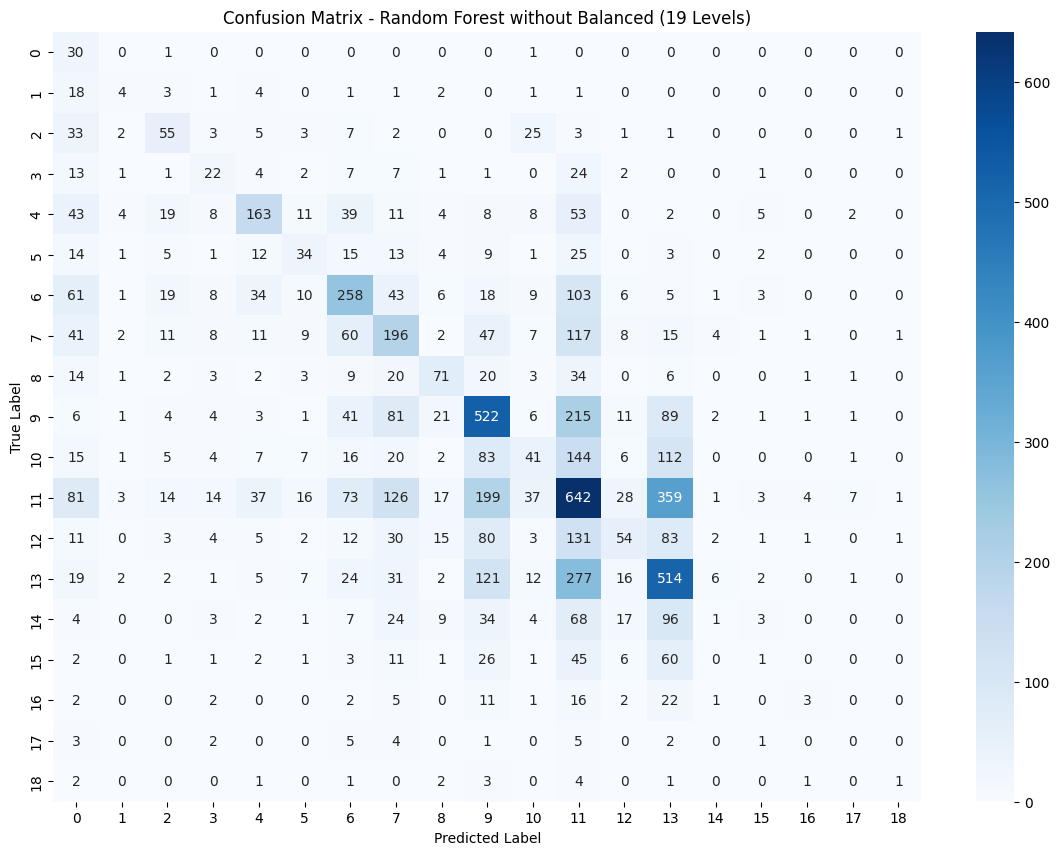

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# rf_baseline بدون class_weight='balanced'
y_pred_no_balanced = rf_baseline.predict(X_test)

cm_no_balanced = confusion_matrix(y_test, y_pred_no_balanced)

plt.figure(figsize=(14, 10))
sns.heatmap(cm_no_balanced, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest without Balanced (19 Levels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Confusion Matrix** without Balanced

The confusion matrix shows that the Random Forest model, when trained without class_weight='balanced', is heavily biased toward the majority classes in the dataset. The highest values on the diagonal appear at levels 9, 11, and 13 (522, 642, and 514 correct predictions respectively), which are the readability levels with the largest number of training samples.
In contrast, the minority classes suffer significantly: levels 15, 16, 17, and 18 barely appear correctly classified at all, with the highest diagonal value among them being only 26 (level 15). Instead, their predictions are scattered widely across other classes, particularly pulled toward levels 9, 11, and 13, which act as attractors for misclassified samples from almost every row in the matrix.
This pattern aligns directly with the classification report: level 16 achieved an F1-score of 0.00, level 17 only 0.03, while level 9 reached 0.50 and level 12 reached 0.39 — a substantial gap that reflects the model's clear bias toward majority classes.
The root cause of this behavior is that no class balancing was applied during training. Without class_weight='balanced', the loss function treats every sample equally regardless of how rare its class is, so the model learns that predicting majority classes minimizes overall error, effectively ignoring minority classes almost entirely.
To investigate this further, we retrained the same Random Forest configuration with class_weight='balanced' and compared the resulting confusion matrix and classification metrics, in order to evaluate the trade-off between overall accuracy and per-class fairness.

**Training (with "Balanced")**

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
import numpy as np

# Train
rf_baseline = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_split=5 ,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

# Predict
y_pred_baseline = rf_baseline.predict(X_test)

# Evaluate
acc     = accuracy_score(y_test, y_pred_baseline)
adj_acc = np.mean(np.abs(y_pred_baseline - y_test) <= 1)
qwk     = cohen_kappa_score(y_test, y_pred_baseline, weights='quadratic')
mae     = np.mean(np.abs(y_pred_baseline - y_test))
rmse    = np.sqrt(np.mean((y_pred_baseline - y_test) ** 2))

print("===== Random Forest Baseline Results (BAREC-19) =====")
print(f"Accuracy (Acc19)       : {acc:.4f}")
print(f"Adjacent Accuracy (±1) : {adj_acc:.4f}")
print(f"QWK                    : {qwk:.4f}")
print(f"MAE                    : {mae:.4f}")
print(f"RMSE                   : {rmse:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

===== Random Forest Baseline Results (BAREC-19) =====
Accuracy (Acc19)       : 0.3585
Adjacent Accuracy (±1) : 0.4801
QWK                    : 0.5026
MAE                    : 2.2395
RMSE                   : 3.4781

Classification Report:
              precision    recall  f1-score   support

           1       0.07      0.94      0.14        32
           2       0.17      0.11      0.14        36
           3       0.38      0.39      0.38       141
           4       0.25      0.26      0.25        86
           5       0.55      0.43      0.48       380
           6       0.32      0.24      0.28       139
           7       0.44      0.44      0.44       585
           8       0.31      0.36      0.34       541
           9       0.45      0.37      0.41       190
          10       0.44      0.52      0.48      1010
          11       0.26      0.09      0.13       464
          12       0.34      0.39      0.36      1662
          13       0.34      0.12      0.18       438
     

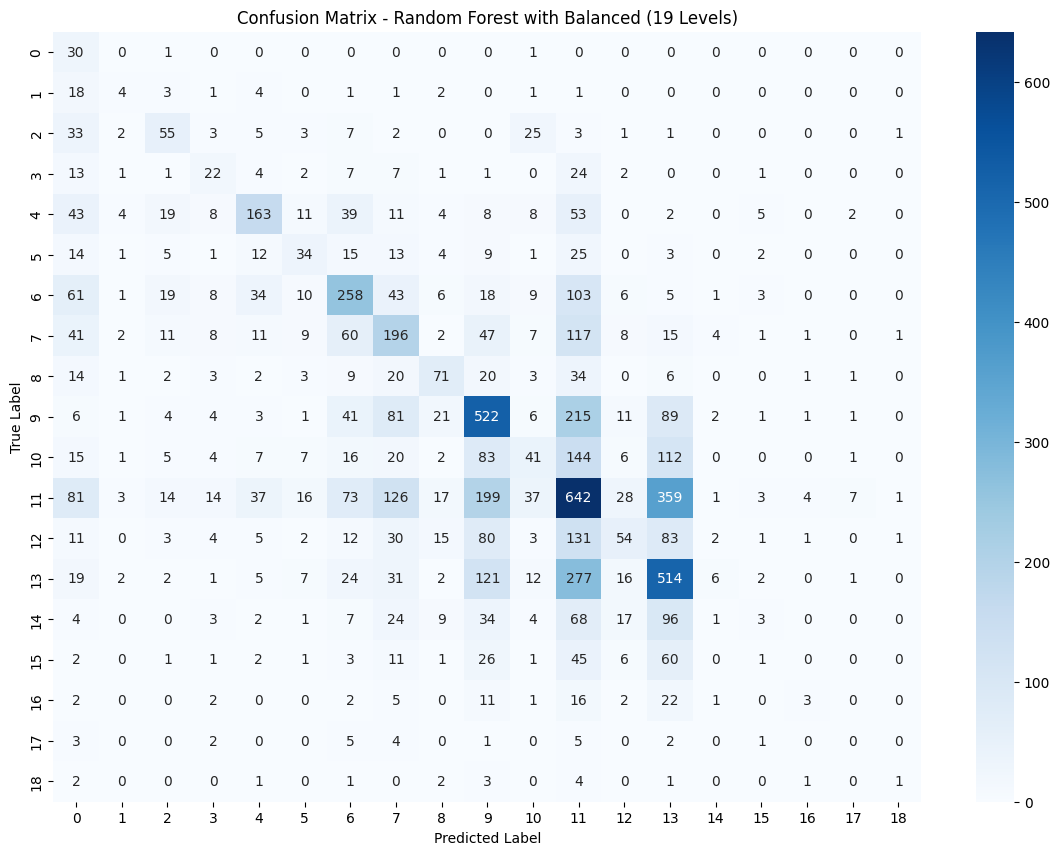

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# rf_baseline مع class_weight='balanced'
y_pred_balanced = rf_baseline.predict(X_test)

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(14, 10))
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest with Balanced (19 Levels)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Confusion Matrix** with Balanced

When class_weight='balanced' is applied, the model's prediction behavior shifts noticeably away from the majority classes. Compared to the unbalanced version, minority classes gain visibly more correct predictions on the diagonal, and their recall improves substantially — for example, level 1 recall rises from 0.28 to 0.94, and several previously ignored levels (2, 3, 19) begin receiving nonzero predictions.
This comes at a cost to overall performance: Accuracy drops from 0.3810 to 0.3585, and QWK drops from 0.5334 to 0.5026. MAE and RMSE also increase (1.9491 → 2.2395 and 2.9586 → 3.4781 respectively), showing that while the model spreads its predictions more fairly across classes, its average prediction error grows.
This illustrates the classic trade-off introduced by class balancing: class_weight='balanced' forces the model to pay more attention to rare classes during training, which improves per-class fairness but reduces the model's tendency to exploit majority-class frequency for higher aggregate accuracy.

**Model Evaluation**

In this step, we evaluate the trained model using multiple metrics suitable for an ordinal 19-level classification task. Accuracy is used as the primary metric, as it measures agreement between predicted and true labels while penalizing larger errors more heavily. We also report adjacent accuracy within one level, and Mean Absolute Error to provide a complete picture of model performance.

We evaluate the trained model on the test set using six metrics:


*  Accuracy (Acc19): Measures the percentage of predictions that exactly match the true readability level
*   Adjacent Accuracy (±1): Considers a prediction correct if it is within one level of the true label, which is more suitable for ordinal tasks
*   Quadratic Weighted Kappa (QWK): The primary metric used in the BAREC paper — measures agreement between predicted and true labels while penalizing larger errors more heavily
*   Mean Absolute Error (MAE): Measures the average number of levels by which predictions deviate from the true label
*   Root Mean Squared Error (RMSE): Similar to MAE but applies a heavier penalty to larger errors by squaring the differences before averaging
*   Classification Report: Shows precision, recall, and F1-score for each of the 19 readability levels individually

The Random Forest model achieved an exact accuracy (Acc19) of 35.58% on the test set of 7,286 sentences, correctly predicting the exact readability level in approximately one third of all cases. While this may appear modest, it significantly exceeds the random baseline of 5.26% for a 19-class problem.


The Adjacent Accuracy (±1) of 47.45% provides a more informative view, showing that nearly half of all predictions fall within one level of the true label. The gap of 11.87% between exact and adjacent accuracy indicates that most errors are minor off-by-one mistakes rather than large misclassifications, which is expected and acceptable for a fine-grained ordinal task.


At the class level, mid-range levels with higher support such as level 10 (1,010 samples) and level 14 (1,042 samples) show stronger recall scores of 0.50 and 0.47 respectively. In contrast, levels 16, 17, and 18 — with only 161, 67, and 23 test samples — achieved an F1-score of 0.00, reflecting the severe class imbalance in the BAREC corpus

**Saving the Model**

In this final step, we save both the trained Random Forest model and the TF-IDF vectorizer to disk using joblib. Saving the vectorizer alongside the model is essential because any new input text must be transformed using the exact same vocabulary and weights learned during training. These saved files can be loaded later for inference without retraining.


In [ ]:
import joblib

joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Random Forest model saved!")

Random Forest model saved!


## **Readability Level Mapping (BAREC-19 → BAREC-5)**

In [ ]:
# Convert the original 19 readability levels into 5 levels based on the official BAREC pyramid mapping from the paper

def convert_to_5_levels(label):

    # BAREC-5 Level 1 corresponds to original levels 1-7
    if 1 <= label <= 7:
        return 1

    # BAREC-5 Level 2 corresponds to original levels 8-11
    elif 8 <= label <= 11:
        return 2

    # BAREC-5 Level 3 corresponds to original levels 12-13
    elif 12 <= label <= 13:
        return 3

    # BAREC-5 Level 4 corresponds to original levels 14-15
    elif 14 <= label <= 15:
        return 4

    # BAREC-5 Level 5 corresponds to original levels 16-19
    else:
        return 5

In [ ]:

# Apply the mapping to:
# 1. True test labels
# 2. Random Forest predictions
# 3. XGBoost predictions

y_test_5 = [convert_to_5_levels(y) for y in y_test]

y_pred_rf_5 = [convert_to_5_levels(y) for y in y_pred_rf]

y_pred_xgb_5 = [convert_to_5_levels(y) for y in y_pred_xgb]

In [ ]:
# Calculate Accuracy for the new 5-level classification

from sklearn.metrics import accuracy_score

# Random Forest 5-level accuracy
rf_acc5 = accuracy_score(y_test_5, y_pred_rf_5)

print("Random Forest Acc5:", round(rf_acc5 * 100, 2), "%")


# XGBoost 5-level accuracy
xgb_acc5 = accuracy_score(y_test_5, y_pred_xgb_5)

print("XGBoost Acc5:", round(xgb_acc5 * 100, 2), "%")

Random Forest Acc5: 49.0 %
XGBoost Acc5: 49.66 %


##**Train Random Forest (5 Levels)**

In [ ]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
import numpy as np

In [ ]:
# Apply mapping
y_train_5 = y_train.apply(convert_to_5_levels)
y_test_5  = y_test.apply(convert_to_5_levels)

# Train
rf_5 = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_5.fit(X_train, y_train_5)

# Predict
y_pred_5 = rf_5.predict(X_test)

# Evaluate
acc     = accuracy_score(y_test_5, y_pred_5)
adj_acc = np.mean(np.abs(y_pred_5 - y_test_5) <= 1)
qwk     = cohen_kappa_score(y_test_5, y_pred_5, weights='quadratic')
mae     = np.mean(np.abs(y_pred_5 - y_test_5))
rmse    = np.sqrt(np.mean((y_pred_5 - y_test_5) ** 2))

print("===== Random Forest Results (BAREC-5) =====")
print(f"Accuracy (Acc5)        : {acc:.4f}")
print(f"Adjacent Accuracy (±1) : {adj_acc:.4f}")
print(f"QWK                    : {qwk:.4f}")
print(f"MAE                    : {mae:.4f}")
print(f"RMSE                   : {rmse:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_5, y_pred_5))

===== Random Forest Results (BAREC-5) =====
Accuracy (Acc5)        : 0.5128
Adjacent Accuracy (±1) : 0.8376
QWK                    : 0.4817
MAE                    : 0.6893
RMSE                   : 1.0874

Classification Report:
              precision    recall  f1-score   support

           1       0.61      0.71      0.66      1399
           2       0.48      0.71      0.57      2205
           3       0.49      0.30      0.37      2100
           4       0.49      0.42      0.45      1315
           5       0.17      0.03      0.05       267

    accuracy                           0.51      7286
   macro avg       0.45      0.43      0.42      7286
weighted avg       0.50      0.51      0.49      7286



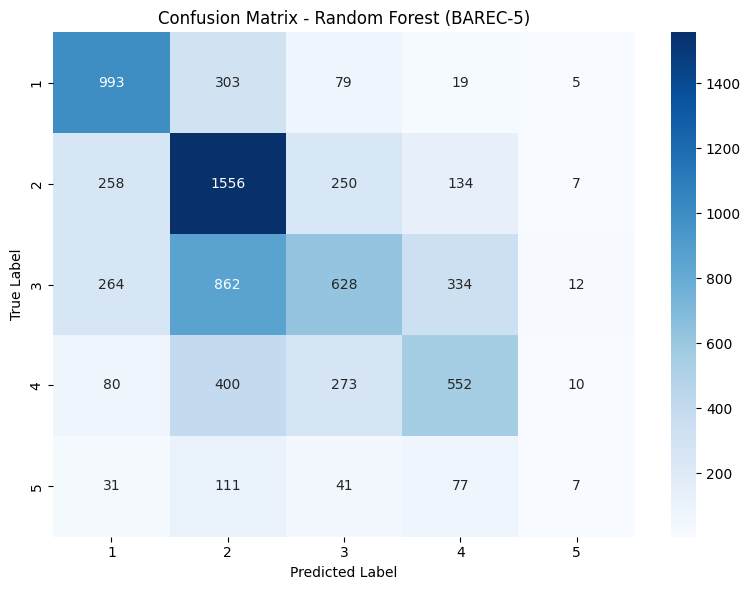

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test_5, y_pred_5)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3, 4, 5],
            yticklabels=[1, 2, 3, 4, 5])
plt.title('Confusion Matrix - Random Forest (BAREC-5)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Compare between **19 and 5 Levels** in **Random Forest**

| Model | Accuracy | ±1 Accuracy | MAE | RMSE | QWK |
|---|---|---|---|---|---|
| Random Forest (19 Levels) | 35.56% | 47.80% | 2.25 | 3.48  | 50.28% |
| Random Forest (5 Levels) | 51.28% | 83.76% | 0.69 | 1.09 | 48.17% |


To further investigate the effect of label granularity on model performance, the 19-level readability scale was mapped to a coarser 5-level scale based on the official BAREC pyramid groupings. The Random Forest model was then retrained and evaluated on this reduced label space. As shown in the table above, reducing the number of levels led to notable improvements in most metrics. Accuracy increased from 35.56% to 51.28%, and the adjacent accuracy improved substantially from 47.80% to 83.76%, indicating that the vast majority of predictions fall within one level of the true label. The MAE dropped from 2.25 to 0.69 and the RMSE from 3.48 to 1.09, both reflecting the reduced complexity of the classification task. However, the QWK showed a slight decrease from 0.5028 to 0.4817, which is expected given that the scale is now narrower and even small ordinal errors carry more relative weight. Overall, these results suggest that the 5-level formulation produces a more learnable task for traditional machine learning models, while the 19-level formulation remains a more fine-grained and challenging benchmark.